# 02 — Preprocesing & Feature selection

# 1. Data loading

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("data/raw/modified_GermanCredit.csv")

df.head()

,status,duration,credit_history,purpose,amount,savings,employment_duration,installment_rate,personal_status_sex,other_debtors,...,property,age,other_installment_plans,housing,number_credits,job,people_liable,telephone,foreign_worker,credit_risk
0,... < 100 DM,6,critical account/other credits existing,domestic appliances,1169,unknown/no savings account,... >= 7 years,4,male : single,none,...,real estate,67,none,own,2,skilled employee/official,1,yes,yes,1
1,0 <= ... < 200 DM,48,existing credits paid back duly till now,domestic appliances,5951,... < 100 DM,1 <= ... < 4 years,2,female : divorced/separated/married,none,...,real estate,22,none,own,1,skilled employee/official,1,no,yes,0
2,no checking account,12,critical account/other credits existing,retraining,2096,... < 100 DM,4 <= ... < 7 years,2,male : single,none,...,real estate,49,none,own,1,unskilled - resident,2,no,yes,1
3,... < 100 DM,42,existing credits paid back duly till now,radio/television,7882,... < 100 DM,4 <= ... < 7 years,2,male : single,guarantor,...,building society savings agreement/life insurance,45,none,for free,1,skilled employee/official,2,no,yes,1
4,... < 100 DM,24,delay in paying off in the past,car (new),4870,... < 100 DM,1 <= ... < 4 years,3,male : single,none,...,unknown/no property,53,none,for free,2,skilled employee/official,2,no,yes,0


In [3]:
X = df.drop(columns=["credit_risk"]) # 20 features
y = df["credit_risk"] # target

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1000, 20)
y shape: (1000,)


In [4]:
numerical_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

print("Numerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features)

print("\nNumber of numerical features:", len(numerical_features))
print("Number of categorical features:", len(categorical_features))

Numerical features:
['duration', 'amount', 'installment_rate', 'present_residence', 'age', 'number_credits', 'people_liable']

Categorical features:
['status', 'credit_history', 'purpose', 'savings', 'employment_duration', 'personal_status_sex', 'other_debtors', 'property', 'other_installment_plans', 'housing', 'job', 'telephone', 'foreign_worker']

Number of numerical features: 7
Number of categorical features: 13


# 2. Train/Test split

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (800, 20)
X_test : (200, 20)
y_train: (800,)
y_test : (200,)


In [6]:
print("Train distribution:")
print(y_train.value_counts(normalize=True))

print("\nTest distribution:")
print(y_test.value_counts(normalize=True))

Train distribution:
credit_risk
1    0.7
0    0.3
Name: proportion, dtype: float64

Test distribution:
credit_risk
1    0.7
0    0.3
Name: proportion, dtype: float64


# 3. Categorical Encoding


In [7]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

In [8]:
encoder.fit(X_train[categorical_features])

,categories,'auto'
,drop,None
,sparse_output,False
,dtype,<class 'numpy.float64'>
,handle_unknown,'ignore'
,min_frequency,None
,max_categories,None
,feature_name_combiner,'concat'


In [9]:
X_train_cat_encoded = encoder.transform(X_train[categorical_features])

X_test_cat_encoded = encoder.transform(X_test[categorical_features])

In [10]:
encoded_feature_names = encoder.get_feature_names_out(categorical_features)

encoded_feature_names

array(['status_... < 100 DM',
       'status_... >= 200 DM / salary for at least 1 year',
       'status_0 <= ... < 200 DM', 'status_no checking account',
       'credit_history_all credits at this bank paid back duly',
       'credit_history_critical account/other credits existing',
       'credit_history_delay in paying off in the past',
       'credit_history_existing credits paid back duly till now',
       'credit_history_no credits taken/all credits paid back duly',
       'purpose_business', 'purpose_car (new)', 'purpose_car (used)',
       'purpose_domestic appliances', 'purpose_education',
       'purpose_furniture/equipment', 'purpose_others',
       'purpose_radio/television', 'purpose_repairs',
       'purpose_retraining', 'savings_... < 100 DM',
       'savings_... >= 1000 DM', 'savings_100 <= ... < 500 DM',
       'savings_500 <= ... < 1000 DM',
       'savings_unknown/no savings account',
       'employment_duration_... < 1 year',
       'employment_duration_... >= 7 yea

In [11]:
X_train_cat_encoded = pd.DataFrame(
    X_train_cat_encoded,
    columns=encoded_feature_names,
    index=X_train.index
)

X_test_cat_encoded = pd.DataFrame(
    X_test_cat_encoded,
    columns=encoded_feature_names,
    index=X_test.index
)

X_train_cat_encoded.head()

,status_... < 100 DM,status_... >= 200 DM / salary for at least 1 year,status_0 <= ... < 200 DM,status_no checking account,credit_history_all credits at this bank paid back duly,credit_history_critical account/other credits existing,credit_history_delay in paying off in the past,credit_history_existing credits paid back duly till now,credit_history_no credits taken/all credits paid back duly,purpose_business,...,housing_own,housing_rent,job_management/self-employed/highly qualified employee/officer,job_skilled employee/official,job_unemployed/unskilled - non-resident,job_unskilled - resident,telephone_no,telephone_yes,foreign_worker_no,foreign_worker_yes
675,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
703,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0
12,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0
845,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0
795,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0


In [12]:
X_train_num = X_train[numerical_features]
X_test_num = X_test[numerical_features]

X_train_encoded = pd.concat(
    [X_train_num, X_train_cat_encoded],
    axis=1
)

X_test_encoded = pd.concat(
    [X_test_num, X_test_cat_encoded],
    axis=1
)

print("Before encoding:", X_train.shape)
print("After encoding :", X_train_encoded.shape)

X_train_encoded.head()

Before encoding: (800, 20)
After encoding : (800, 61)


,duration,amount,installment_rate,present_residence,age,number_credits,people_liable,status_... < 100 DM,status_... >= 200 DM / salary for at least 1 year,status_0 <= ... < 200 DM,...,housing_own,housing_rent,job_management/self-employed/highly qualified employee/officer,job_skilled employee/official,job_unemployed/unskilled - non-resident,job_unskilled - resident,telephone_no,telephone_yes,foreign_worker_no,foreign_worker_yes
675,30,4530,4,4,26,1,1,0.0,0.0,0.0,...,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
703,30,2503,4,2,41,2,1,0.0,0.0,1.0,...,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0
12,12,1567,1,1,22,1,1,0.0,0.0,1.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0
845,21,3976,2,3,35,1,1,0.0,0.0,1.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0
795,9,2301,2,4,22,1,1,0.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0


## 4. Chi-square Test for Categorical Features

In [13]:
from scipy.stats import chi2_contingency

chi2_results = []

for col in categorical_features:
    contingency_table = pd.crosstab(X_train[col], y_train)

    chi2, p_value, dof, expected = chi2_contingency(contingency_table)

    chi2_results.append({
        "feature": col,
        "chi2": chi2,
        "p_value": p_value
    })

chi2_results = pd.DataFrame(chi2_results)

chi2_results = chi2_results.sort_values(by="p_value")

chi2_results

chi2_results["significant"] = (chi2_results["p_value"] < 0.05)

chi2_results

,feature,chi2,p_value,significant
0,status,99.584245,1.909363e-21,True
1,credit_history,45.341019,3.376995e-09,True
2,purpose,43.496530,1.747203e-06,True
3,savings,27.950842,1.276235e-05,True
7,property,18.626217,3.266230e-04,True
8,other_installment_plans,12.293916,2.139982e-03,True
9,housing,11.630374,2.981923e-03,True
4,employment_duration,15.105677,4.486980e-03,True
6,other_debtors,9.694478,7.850021e-03,True
12,foreign_worker,4.231434,3.968191e-02,True


## 5. Random Forest Feature Importance


In [14]:
from sklearn.ensemble import RandomForestClassifier

rf_selector = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced"
)

rf_selector.fit(X_train_encoded, y_train)


rf_importance = pd.DataFrame({
    "feature": X_train_encoded.columns,
    "importance": rf_selector.feature_importances_
})

rf_importance = rf_importance.sort_values(
    by="importance",
    ascending=False
)

rf_importance.head(20)

,feature,importance
1,amount,0.091039
0,duration,0.081885
4,age,0.077492
10,status_no checking account,0.063509
7,status_... < 100 DM,0.036306
2,installment_rate,0.033084
3,present_residence,0.032525
12,credit_history_critical account/other credits ...,0.024803
26,savings_... < 100 DM,0.021730
9,status_0 <= ... < 200 DM,0.018512


## 6. Aggregate Random Forest Importance


In [15]:
original_rf_importance = []

for col in numerical_features:
    importance = rf_importance.loc[
        rf_importance["feature"] == col,
        "importance"
    ].sum()

    original_rf_importance.append({
        "feature": col,
        "rf_importance": importance
    })

for col in categorical_features:
    importance = rf_importance.loc[
        rf_importance["feature"].str.startswith(f"{col}_"),
        "importance"
    ].sum()

    original_rf_importance.append({
        "feature": col,
        "rf_importance": importance
    })

original_rf_importance = pd.DataFrame(original_rf_importance)

original_rf_importance = original_rf_importance.sort_values(
    by="rf_importance",
    ascending=False
).reset_index(drop=True)

original_rf_importance

,feature,rf_importance
0,status,0.127173
1,amount,0.091039
2,purpose,0.090140
3,duration,0.081885
4,age,0.077492
5,savings,0.058038
6,employment_duration,0.056547
7,credit_history,0.056430
8,property,0.055063
9,personal_status_sex,0.044128


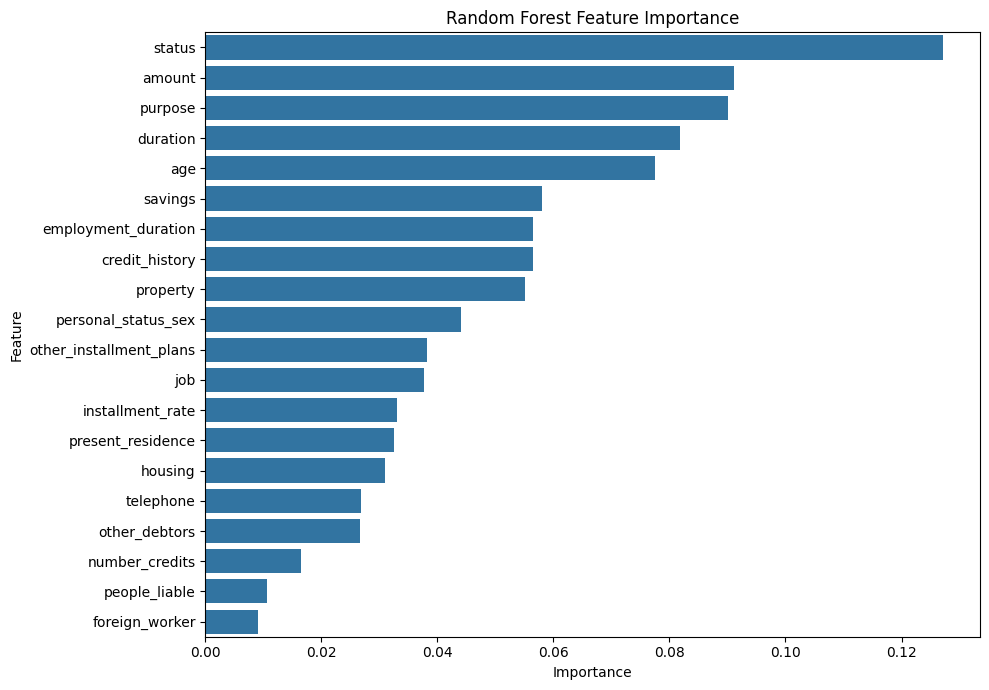

In [16]:
plt.figure(figsize=(10, 7))

sns.barplot(
    data=original_rf_importance,
    x="rf_importance",
    y="feature"
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

## 7. Combined Feature Selection Summary


In [17]:
chi2_summary = chi2_results[
    ["feature", "p_value", "significant"]
].copy()

feature_summary = original_rf_importance.merge(
    chi2_summary,
    on="feature",
    how="left"
)

feature_summary

,feature,rf_importance,p_value,significant
0,status,0.127173,1.909363e-21,True
1,amount,0.091039,NaN,NaN
2,purpose,0.090140,1.747203e-06,True
3,duration,0.081885,NaN,NaN
4,age,0.077492,NaN,NaN
5,savings,0.058038,1.276235e-05,True
6,employment_duration,0.056547,4.486980e-03,True
7,credit_history,0.056430,3.376995e-09,True
8,property,0.055063,3.266230e-04,True
9,personal_status_sex,0.044128,7.085445e-02,False


## 8. Final Feature Selection


In [18]:
feature_summary = feature_summary.sort_values(
    by="rf_importance",
    ascending=False
).reset_index(drop=True)

feature_summary["rf_rank"] = range(1, len(feature_summary) + 1)

feature_summary

feature_summary["chi2_not_significant"] = (
    feature_summary["significant"] == False
)

feature_summary

,feature,rf_importance,p_value,significant,rf_rank,chi2_not_significant
0,status,0.127173,1.909363e-21,True,1,False
1,amount,0.091039,NaN,NaN,2,False
2,purpose,0.090140,1.747203e-06,True,3,False
3,duration,0.081885,NaN,NaN,4,False
4,age,0.077492,NaN,NaN,5,False
5,savings,0.058038,1.276235e-05,True,6,False
6,employment_duration,0.056547,4.486980e-03,True,7,False
7,credit_history,0.056430,3.376995e-09,True,8,False
8,property,0.055063,3.266230e-04,True,9,False
9,personal_status_sex,0.044128,7.085445e-02,False,10,True


## 9. Candidate Feature Sets


In [19]:
all_features = X.columns.tolist()

features_without_telephone = [col for col in all_features if col != "telephone"]

features_without_telephone_job = [col for col in all_features if col not in ["telephone", "job"]]

print("Original:", len(all_features))
print("Without telephone:", len(features_without_telephone))
print("Without telephone & job:", len(features_without_telephone_job))

Original: 20
Without telephone: 19
Without telephone & job: 18


## 10. Validate Candidate Feature Sets


In [20]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_validate

In [21]:
def evaluate_feature_set(feature_list, name):
    num_cols = [col for col in numerical_features if col in feature_list]

    cat_cols = [col for col in categorical_features if col in feature_list]

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", StandardScaler(), num_cols),
            ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
        ]
    )

    model = LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    )

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    cv = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    )

    scores = cross_validate(
        pipeline,
        X_train[feature_list],
        y_train,
        cv=cv,
        scoring={
            "roc_auc": "roc_auc",
            "f1_macro": "f1_macro"
        }
    )

    return {
        "feature_set": name,
        "n_features": len(feature_list),
        "roc_auc_mean": scores["test_roc_auc"].mean(),
        "roc_auc_std": scores["test_roc_auc"].std(),
        "f1_macro_mean": scores["test_f1_macro"].mean(),
        "f1_macro_std": scores["test_f1_macro"].std()
    }

In [22]:
results = []

results.append(evaluate_feature_set(all_features, "All features"))

results.append(evaluate_feature_set(features_without_telephone, "Without telephone"))

results.append(evaluate_feature_set(features_without_telephone_job, "Without telephone + job"))

comparison_df = pd.DataFrame(results)

comparison_df

,feature_set,n_features,roc_auc_mean,roc_auc_std,f1_macro_mean,f1_macro_std
0,All features,20,0.787165,0.067699,0.708415,0.068879
1,Without telephone,19,0.786942,0.072135,0.709452,0.060533
2,Without telephone + job,18,0.790513,0.073139,0.704052,0.058888


### 11. Final Feature Selection Decision


In [23]:
final_features = [col for col in X.columns if col not in ["telephone", "job"]]

print("Number of final features:", len(final_features))
print(final_features)

Number of final features: 18
['status', 'duration', 'credit_history', 'purpose', 'amount', 'savings', 'employment_duration', 'installment_rate', 'personal_status_sex', 'other_debtors', 'present_residence', 'property', 'age', 'other_installment_plans', 'housing', 'number_credits', 'people_liable', 'foreign_worker']


## 12. Create Final Train/Test Data


In [24]:
X_train_final = X_train[final_features].copy()
X_test_final = X_test[final_features].copy()

print("X_train_final:", X_train_final.shape)
print("X_test_final :", X_test_final.shape)

X_train_final: (800, 18)
X_test_final : (200, 18)


In [25]:
train_final = X_train_final.copy()
train_final["credit_risk"] = y_train

test_final = X_test_final.copy()
test_final["credit_risk"] = y_test

print("Final train:", train_final.shape)
print("Final test :", test_final.shape)

Final train: (800, 19)
Final test : (200, 19)


In [26]:
print("Missing train:", train_final.isnull().sum().sum())
print("Missing test :", test_final.isnull().sum().sum())

print("\nTrain target:")
print(train_final["credit_risk"].value_counts())

print("\nTest target:")
print(test_final["credit_risk"].value_counts())

Missing train: 0
Missing test : 0

Train target:
credit_risk
1    560
0    240
Name: count, dtype: int64

Test target:
credit_risk
1    140
0     60
Name: count, dtype: int64


In [27]:
train_final.to_csv(
    "data/processed/train.csv",
    index=False
)

test_final.to_csv(
    "data/processed/test.csv",
    index=False
)

In [28]:
import json

with open("data/processed/final_features.json", "w") as f:
    json.dump(final_features, f, indent=4)